# Разведочный анализ данных (EDA) для задачи оценки вероятности

## Датасет: **Bank Marketing** (телемаркетинг португальского банка)

| | |
|---|---|
| **Студент** | Руденко Данила |
| **Группа** | 3743805/50801 |
| **Предмет** | Машинное обучение |
| **Тип задачи** | Оценка вероятности наступления события (бинарная классификация) |

## 1. Описание датасета и постановка задачи

**Источник данных:** классический набор *Bank Marketing* (Moro, Cortez & Rita, 2014).
- Страница UCI: https://archive.ics.uci.edu/dataset/222/bank+marketing
- Страница OpenML: https://www.openml.org/d/1461
- Dataset: https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv

Данные собраны по итогам **прямых маркетинговых кампаний** (телефонных звонков) португальского
банка. По каждому клиенту известны его социально-демографические характеристики, история прошлых
контактов и макроэкономические индикаторы на момент звонка. Используется расширенная версия
`bank-additional-full` — **41 188 строк** и **21 столбец** (20 признаков + 1 целевая переменная).

**Целевая переменная `y`** — оформил ли клиент срочный банковский вклад (term deposit) после
кампании: `yes` / `no`.

### Постановка задачи

Требуется **оценить вероятность наступления события** — вероятность того, что конкретный клиент
оформит срочный вклад после телемаркетингового контакта:

$$\hat{p} = P(y = \text{yes} \mid X)$$

где $X$ — вектор признаков клиента (возраст, профессия, тип контакта, исход прошлой кампании,
экономические индикаторы и т. д.).

**Почему это именно задача оценки вероятности.** Целевая переменная бинарна и описывает
наступление/ненаступление события (клиент согласился / не согласился). Модель должна возвращать
не просто метку класса, а **число от 0 до 1** — вероятность согласия, которую банк может
использовать, например, для ранжирования клиентов и приоритизации звонков. Именно наличие
явного бинарного события и признаков, от которых оно зависит, делает датасет пригодным для
данной задачи.


## 2. Подготовка окружения

Устанавливаем `ydata-profiling` (для автоматического EDA-отчёта).


In [1]:
# Установка библиотеки автоматического профилирования
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00


In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

RANDOM_STATE = 42
print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


## 3. Импорт данных

Загружаем датасет напрямую по ссылке (разделитель — точка с запятой `;`).


In [2]:
URL = "https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv"
df = pd.read_csv(URL, sep=";")

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 41188 строк, 21 столбцов


In [3]:
# Первые строки
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 4. Первичный осмотр данных

Смотрим типы столбцов, описательные статистики и пропуски.


In [4]:
# Типы данных и заполненность
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Описательные статистики по числовым признакам
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [6]:
# Явных пропусков (NaN) в датасете нет:
print("Пропусков NaN всего:", int(df.isna().sum().sum()))

# Однако часть категориальных признаков содержит значение 'unknown' —
# это скрытая форма пропуска. Посчитаем такие значения.
cat_cols = df.select_dtypes(include="object").columns
unknown_counts = {c: int((df[c] == "unknown").sum()) for c in cat_cols}
unknown_counts = {c: n for c, n in unknown_counts.items() if n > 0}
pd.Series(unknown_counts, name="Кол-во 'unknown'").sort_values(ascending=False).to_frame()

Пропусков NaN всего: 0


,Кол-во 'unknown'
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


## 5. Целевая переменная и базовая вероятность события

Оценим распределение классов и **базовую (безусловную) вероятность** события —
это отправная точка (baseline) для будущей модели.


In [7]:
# Числовая версия целевой переменной: 1 = вклад оформлен, 0 = нет
df["target"] = (df["y"] == "yes").astype(int)

counts = df["y"].value_counts()
base_rate = df["target"].mean()

print(counts)
print(f"\nБазовая вероятность события P(y = yes) = {base_rate:.4f}  ({base_rate*100:.2f}%)")
print("Вывод: классы несбалансированы — событие 'yes' встречается редко.")

y
no     36548
yes     4640
Name: count, dtype: int64

Базовая вероятность события P(y = yes) = 0.1127  (11.27%)
Вывод: классы несбалансированы — событие 'yes' встречается редко.


/tmp/ipykernel_2419/2273893960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y", data=df, order=["no", "yes"], ax=ax[0], palette=["#4C72B0", "#DD8452"])


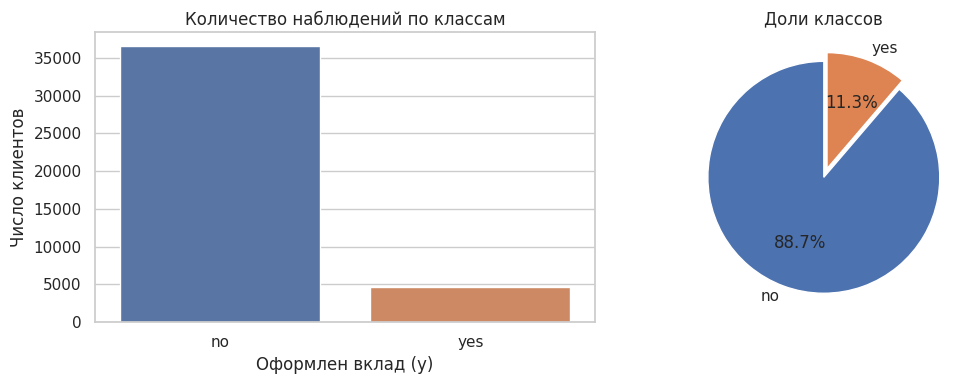

In [8]:
# Визуализация распределения целевой переменной
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="y", data=df, order=["no", "yes"], ax=ax[0], palette=["#4C72B0", "#DD8452"])
ax[0].set_title("Количество наблюдений по классам")
ax[0].set_xlabel("Оформлен вклад (y)"); ax[0].set_ylabel("Число клиентов")

ax[1].pie(counts, labels=["no", "yes"], autopct="%1.1f%%",
          colors=["#4C72B0", "#DD8452"], startangle=90, explode=(0, 0.08))
ax[1].set_title("Доли классов")

plt.tight_layout(); plt.show()

## 6. Как признаки влияют на вероятность события

Ключевая часть разведочного анализа для нашей задачи — посмотреть, как **условная вероятность**
события $P(y=\text{yes} \mid \text{признак})$ меняется в зависимости от значений признаков.
Если вероятность заметно «гуляет» между категориями, признак полезен для модели.

Определим вспомогательную функцию, которая считает и рисует вероятность события по категориям.


In [9]:
def prob_by_category(col, min_count=30, figsize=(8, 4)):
    """Средняя вероятность события P(y=yes) внутри каждой категории признака col."""
    g = (df.groupby(col)["target"]
           .agg(["mean", "count"])
           .rename(columns={"mean": "P(yes)", "count": "n"}))
    g = g[g["n"] >= min_count].sort_values("P(yes)", ascending=False)

    plt.figure(figsize=figsize)
    sns.barplot(x=g["P(yes)"], y=g.index, palette="viridis")
    plt.axvline(df["target"].mean(), color="red", linestyle="--",
                label=f"базовая вероятность = {df['target'].mean():.3f}")
    plt.title(f"Вероятность оформления вклада по признаку «{col}»")
    plt.xlabel("P(y = yes)"); plt.ylabel(col); plt.legend()
    plt.tight_layout(); plt.show()
    return g.round(3)

/tmp/ipykernel_2419/1077384567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g["P(yes)"], y=g.index, palette="viridis")


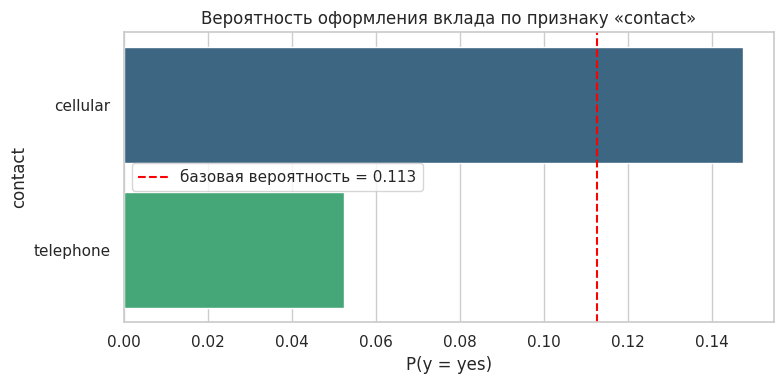

,P(yes),n
contact,,
cellular,0.147,26144
telephone,0.052,15044


In [10]:
# Тип контакта: мобильный телефон заметно результативнее стационарного
prob_by_category("contact")

/tmp/ipykernel_2419/1077384567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g["P(yes)"], y=g.index, palette="viridis")


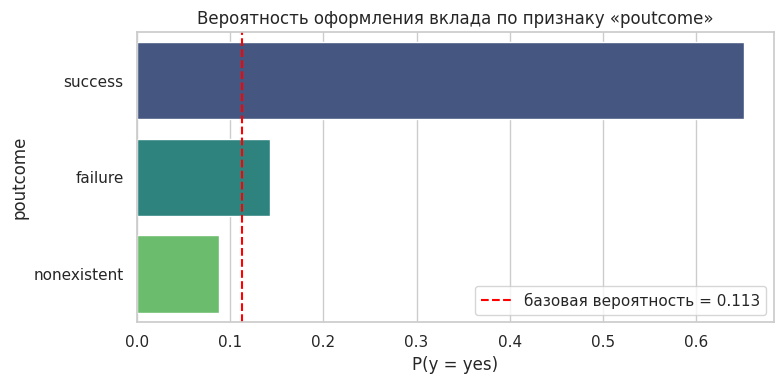

,P(yes),n
poutcome,,
success,0.651,1373
failure,0.142,4252
nonexistent,0.088,35563


In [11]:
# Исход предыдущей кампании — очень сильный признак
prob_by_category("poutcome")

/tmp/ipykernel_2419/1077384567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g["P(yes)"], y=g.index, palette="viridis")


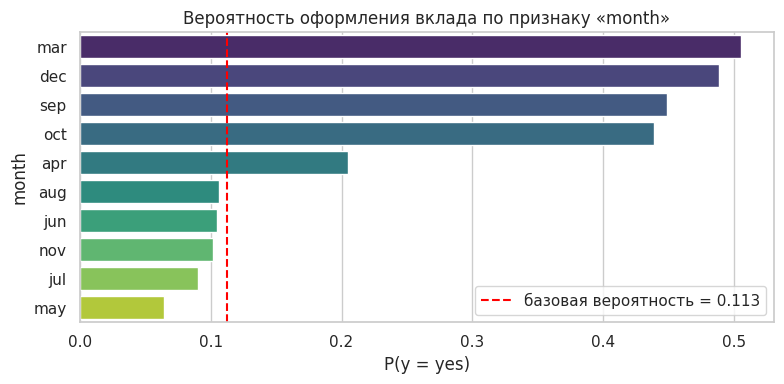

,P(yes),n
month,,
mar,0.505,546
dec,0.489,182
sep,0.449,570
oct,0.439,718
apr,0.205,2632
aug,0.106,6178
jun,0.105,5318
nov,0.101,4101
jul,0.090,7174


In [12]:
# Месяц последнего контакта
prob_by_category("month")

/tmp/ipykernel_2419/1077384567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g["P(yes)"], y=g.index, palette="viridis")


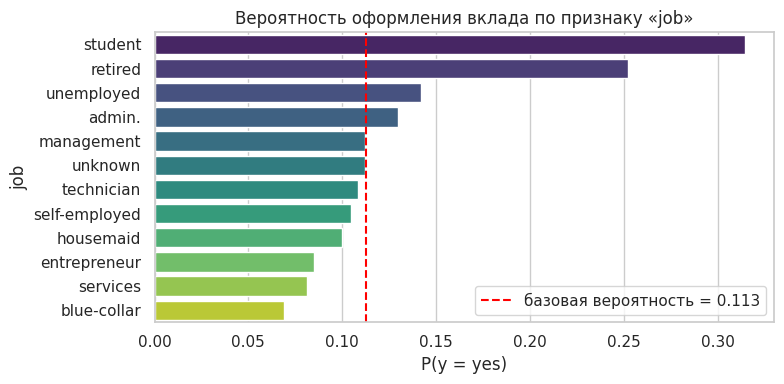

,P(yes),n
job,,
student,0.314,875
retired,0.252,1720
unemployed,0.142,1014
admin.,0.130,10422
management,0.112,2924
unknown,0.112,330
technician,0.108,6743
self-employed,0.105,1421
housemaid,0.100,1060


In [13]:
# Профессия клиента
prob_by_category("job")

Теперь посмотрим на числовые признаки в разрезе целевой переменной — распределения у согласившихся
и отказавшихся клиентов различаются.


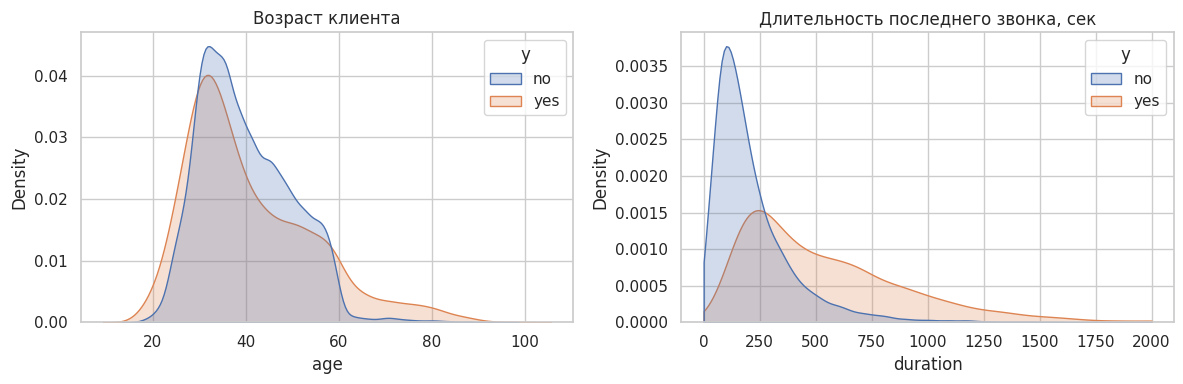

Чем дольше длился разговор (duration), тем выше вероятность согласия.


In [14]:
# Распределение возраста и длительности звонка по классам
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=df, x="age", hue="y", fill=True, common_norm=False, ax=ax[0])
ax[0].set_title("Возраст клиента"); ax[0].set_xlabel("age")

sns.kdeplot(data=df, x="duration", hue="y", fill=True, common_norm=False, clip=(0, 2000), ax=ax[1])
ax[1].set_title("Длительность последнего звонка, сек"); ax[1].set_xlabel("duration")

plt.tight_layout(); plt.show()

print("Чем дольше длился разговор (duration), тем выше вероятность согласия.")

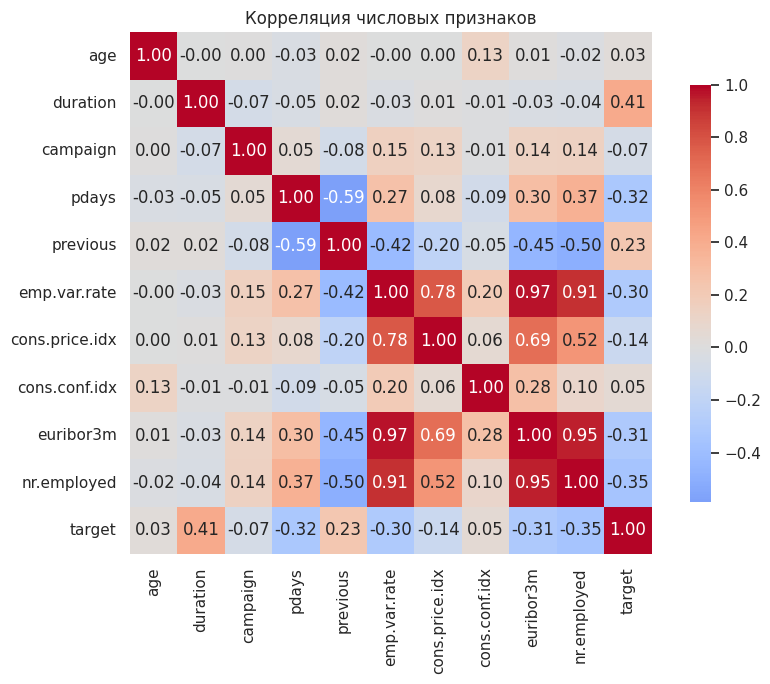

In [15]:
# Корреляционная матрица числовых признаков (включая target)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Корреляция числовых признаков")
plt.tight_layout(); plt.show()

## 7. Автоматический разведочный анализ (ydata-profiling)

Формируем сводный отчёт по всему датасету: типы, статистики, распределения, пропуски,
корреляции и взаимодействия


In [16]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df.drop(columns=["target"]),   # target — производная от y, исключаем во избежание дублирования
    title="Bank Marketing — EDA report",
    explorative=True,
)

/tmp/ipykernel_2419/3416487151.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [17]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:02<00:00,  7.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
# (необязательно) Сохранить отчёт в HTML и скачать на компьютер
profile.to_file("bank_marketing_report.html")

from google.colab import files   # работает только в Google Colab
files.download("bank_marketing_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Выводы

1. **Задача корректна для оценки вероятности.** Целевая переменная `y` бинарна и описывает
   наступление события (оформление вклада). Признаки содержат информацию, от которой это событие
   зависит, поэтому можно строить модель $P(y=\text{yes}\mid X)$.

2. **Классы несбалансированы:** событие `yes` составляет ≈ 11 % наблюдений. Это базовая вероятность,
   относительно которой в дальнейшем оценивается качество модели; при обучении понадобятся метрики,
   устойчивые к дисбалансу (ROC-AUC, PR-AUC), и, возможно, балансировка классов.

3. **Информативные признаки** (условная вероятность заметно отклоняется от базовой):
   - `poutcome` — успех прошлой кампании резко повышает вероятность согласия;
   - `contact` — мобильная связь эффективнее стационарной;
   - `month`, `job`, а также числовые `duration` и `age`.

4. **Пропуски.** Явных `NaN` нет, но в ряде категориальных признаков есть значение `unknown`
   (особенно в `default`, `education`) — на этапе подготовки данных его стоит обработать отдельно.

5. **Следующий шаг** (за рамками этого EDA): кодирование категориальных признаков, разбиение на
   train/test и обучение вероятностной модели (например, логистической регрессии или градиентного
   бустинга) с калибровкой вероятностей.
